Libraries

In [41]:
import pandas as pd
import sklearn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import warnings
warnings.filterwarnings("ignore")

Data Cleaninf and Analysis

In [42]:
final_T = pd.read_csv('train.csv')
final_T

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [43]:
final_T.duplicated().sum()

0

In [44]:
final_T.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [45]:
final_T = final_T.drop(columns=["Cabin"])

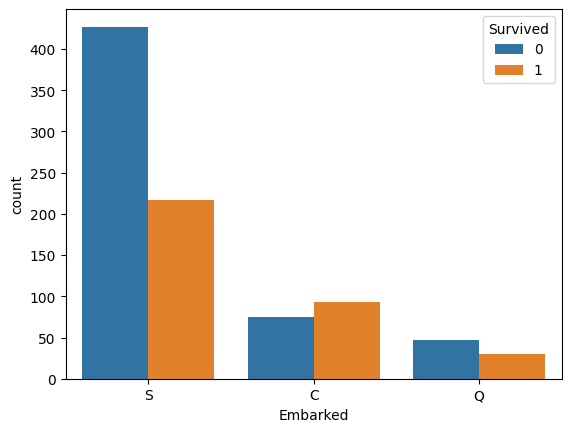

In [46]:
sns.countplot(data=final_T, x="Embarked", hue="Survived")
plt.show()

In [47]:
final_T

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


In [48]:
final_T["Embarked"] = final_T["Embarked"].map({"Q": 0, "C": 1, "S": 2})


In [49]:
final_T

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,2.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,1.0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,2.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,2.0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,2.0
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,2.0
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,2.0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,2.0
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,1.0


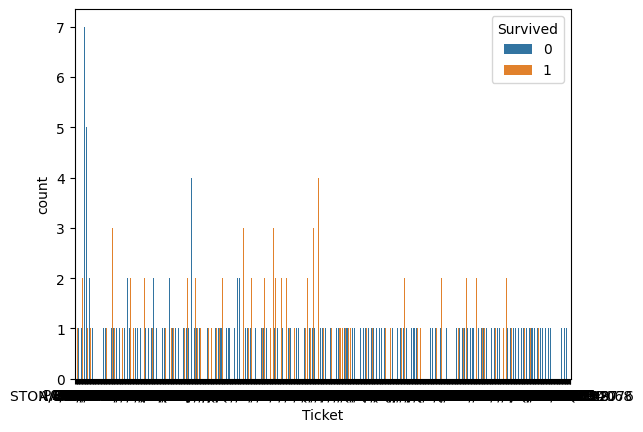

In [50]:
sns.countplot(data=final_T, x="Ticket", hue="Survived")
plt.show()

In [51]:
final_T = final_T.drop(columns=["Name"])
final_T

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,male,22.0,1,0,A/5 21171,7.2500,2.0
1,2,1,1,female,38.0,1,0,PC 17599,71.2833,1.0
2,3,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,2.0
3,4,1,1,female,35.0,1,0,113803,53.1000,2.0
4,5,0,3,male,35.0,0,0,373450,8.0500,2.0
...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,male,27.0,0,0,211536,13.0000,2.0
887,888,1,1,female,19.0,0,0,112053,30.0000,2.0
888,889,0,3,female,NaN,1,2,W./C. 6607,23.4500,2.0
889,890,1,1,male,26.0,0,0,111369,30.0000,1.0


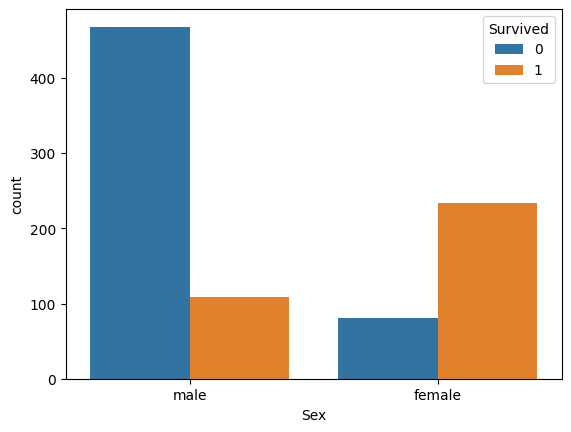

In [52]:
sns.countplot(data=final_T, x="Sex", hue="Survived")
plt.show()

In [53]:
final_T["Sex"] = final_T["Sex"].map({"male": 1, "female": 0})
final_T


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,1,22.0,1,0,A/5 21171,7.2500,2.0
1,2,1,1,0,38.0,1,0,PC 17599,71.2833,1.0
2,3,1,3,0,26.0,0,0,STON/O2. 3101282,7.9250,2.0
3,4,1,1,0,35.0,1,0,113803,53.1000,2.0
4,5,0,3,1,35.0,0,0,373450,8.0500,2.0
...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,1,27.0,0,0,211536,13.0000,2.0
887,888,1,1,0,19.0,0,0,112053,30.0000,2.0
888,889,0,3,0,NaN,1,2,W./C. 6607,23.4500,2.0
889,890,1,1,1,26.0,0,0,111369,30.0000,1.0


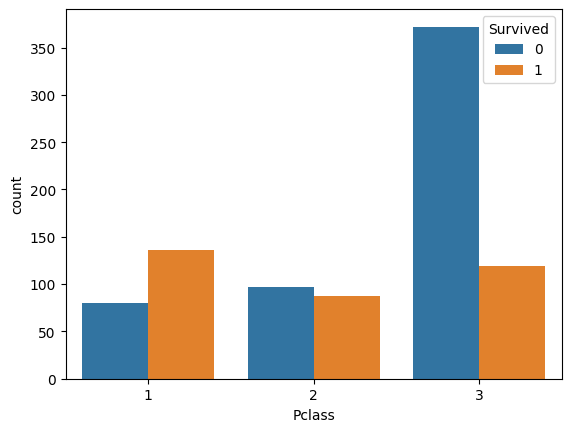

In [54]:
sns.countplot(data=final_T, x="Pclass", hue="Survived")
plt.show()

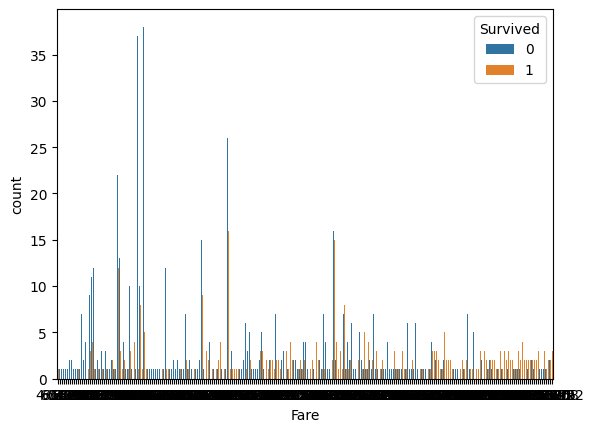

In [55]:
sns.countplot(data=final_T, x="Fare", hue="Survived")
plt.show()

In [56]:
final_T.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         2
dtype: int64

In [57]:
final_T['Age'] = final_T['Age'].fillna(final_T['Age'].median())
final_T.isnull().sum()


PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       2
dtype: int64

In [58]:
final_T

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,1,22.0,1,0,A/5 21171,7.2500,2.0
1,2,1,1,0,38.0,1,0,PC 17599,71.2833,1.0
2,3,1,3,0,26.0,0,0,STON/O2. 3101282,7.9250,2.0
3,4,1,1,0,35.0,1,0,113803,53.1000,2.0
4,5,0,3,1,35.0,0,0,373450,8.0500,2.0
...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,1,27.0,0,0,211536,13.0000,2.0
887,888,1,1,0,19.0,0,0,112053,30.0000,2.0
888,889,0,3,0,28.0,1,2,W./C. 6607,23.4500,2.0
889,890,1,1,1,26.0,0,0,111369,30.0000,1.0


In [59]:
final_T['Embarked'] = final_T['Embarked'].fillna(final_T['Embarked'].median())
final_T.isnull().sum()


PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

<Axes: >

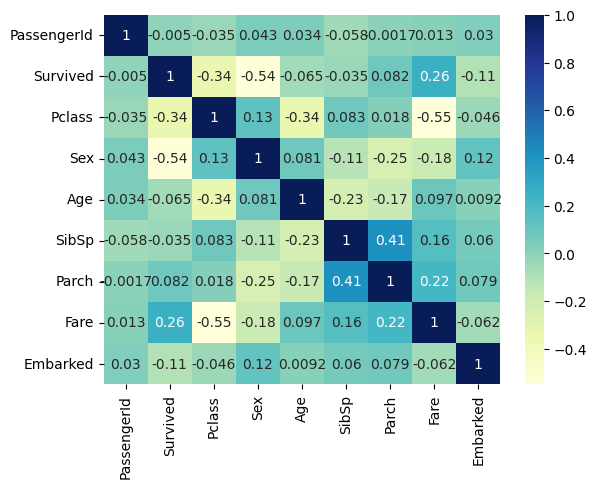

In [60]:
sns.heatmap(final_T.corr(numeric_only=True), cmap="YlGnBu", annot=True)

In [61]:
!pip install statsmodels


In [62]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

features = final_T[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']]

features_with_constant = features.copy()
features_with_constant['constant'] = 1

vif_data = pd.DataFrame()
vif_data["Feature"] = features.columns
vif_data["VIF"] = [variance_inflation_factor(features_with_constant.values, i) for i in range(len(features.columns))]

print(vif_data.round(2))


  Feature   VIF
0  Pclass  1.68
1     Sex  1.10
2     Age  1.21
3   SibSp  1.28
4   Parch  1.31
5    Fare  1.59


In [63]:
final_T['FamilySize']= final_T['SibSp'] + final_T['Parch'] + 1

In [64]:
final_T

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize
0,1,0,3,1,22.0,1,0,A/5 21171,7.2500,2.0,2
1,2,1,1,0,38.0,1,0,PC 17599,71.2833,1.0,2
2,3,1,3,0,26.0,0,0,STON/O2. 3101282,7.9250,2.0,1
3,4,1,1,0,35.0,1,0,113803,53.1000,2.0,2
4,5,0,3,1,35.0,0,0,373450,8.0500,2.0,1
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,1,27.0,0,0,211536,13.0000,2.0,1
887,888,1,1,0,19.0,0,0,112053,30.0000,2.0,1
888,889,0,3,0,28.0,1,2,W./C. 6607,23.4500,2.0,4
889,890,1,1,1,26.0,0,0,111369,30.0000,1.0,1


In [65]:
final_T = final_T.drop(columns=["SibSp", "Parch", "PassengerId", "Age"])

In [66]:
final_T

,Survived,Pclass,Sex,Ticket,Fare,Embarked,FamilySize
0,0,3,1,A/5 21171,7.2500,2.0,2
1,1,1,0,PC 17599,71.2833,1.0,2
2,1,3,0,STON/O2. 3101282,7.9250,2.0,1
3,1,1,0,113803,53.1000,2.0,2
4,0,3,1,373450,8.0500,2.0,1
...,...,...,...,...,...,...,...
886,0,2,1,211536,13.0000,2.0,1
887,1,1,0,112053,30.0000,2.0,1
888,0,3,0,W./C. 6607,23.4500,2.0,4
889,1,1,1,111369,30.0000,1.0,1


<Axes: >

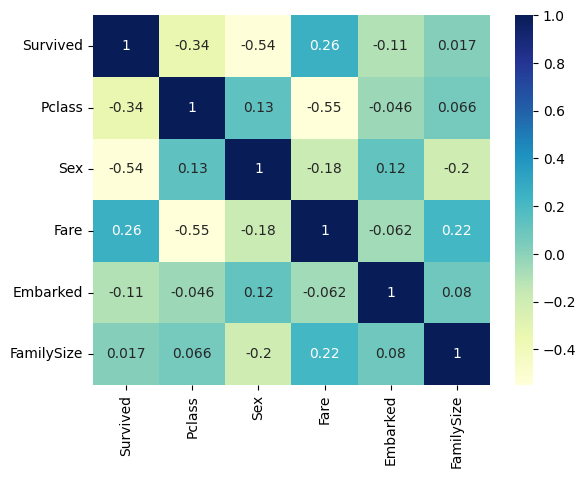

In [67]:
sns.heatmap(final_T.corr(numeric_only=True), cmap="YlGnBu", annot=True)

In [68]:
final_T = final_T.drop(columns=["FamilySize"])

In [69]:
from sklearn.model_selection import train_test_split

In [77]:
X = final_T.drop('Survived', axis=1)
y = final_T['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [87]:
print("Available columns:", X_train.columns.tolist())


Available columns: ['Pclass', 'Sex', 'Ticket', 'Fare', 'Embarked']


Model Build


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

all_numeric = ['Age', 'Fare', 'Pclass', 'FamilySize']
all_categorical = ['Sex', 'Embarked']

num_features = [col for col in all_numeric if col in X_train.columns]
cat_features = [col for col in all_categorical if col in X_train.columns]

print(f"Pipeline will process Numeric columns: {num_features}")
print(f"Pipeline will process Categorical columns: {cat_features}")

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_features),
        ('cat', cat_pipeline, cat_features)
    ],
    remainder='drop'  
)

final_model_pipeline = Pipeline([
    ('preprocessing', preprocessor),          
    ('logistic_regression', LogisticRegression(max_iter=1000)) 
])

final_model_pipeline.fit(X_train, y_train)

# 5. Generate test predictions
y_pred = final_model_pipeline.predict(X_test)
y_pred_prob = final_model_pipeline.predict_proba(X_test)[:, 1]

# 6. Print out the final error-free metrics scorecard
print("\nModel Performance Summary:")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.2f}")
print(f"Precision : {precision_score(y_test, y_pred):.2f}")
print(f"Recall : {recall_score(y_test, y_pred):.2f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.2f}")
print(f"AUC-ROC : {roc_auc_score(y_test, y_pred_prob):.2f}")


ValueError: A given column is not a column of the dataframe